<a href="https://colab.research.google.com/github/Shashank18ram/NMS/blob/main/NMSDay2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Recording table (handover events included):

    Time Node Cell Antenna                 Event
18:15:55   N1   C4    A-C4    New entry recorded
18:15:55   N2  C12   A-C12    New entry recorded
18:15:55   N3  C17   A-C17    New entry recorded
18:15:57   N3  C14   A-C14 Handover (C17 -> C14)
18:15:58   N1   C0    A-C0   Handover (C4 -> C0)
18:15:58   N2   C7    A-C7  Handover (C12 -> C7)
18:16:00   N3  C10   A-C10 Handover (C14 -> C10)
18:16:03   N3   C5    A-C5  Handover (C10 -> C5)
18:16:04   N2   C3    A-C3   Handover (C7 -> C3)
18:16:06   N3   C4    A-C4   Handover (C5 -> C4)
18:16:06   N1   C1    A-C1   Handover (C0 -> C1)
18:16:08   N2   C0    A-C0   Handover (C3 -> C0)
18:16:08   N3   C0    A-C0   Handover (C4 -> C0)
18:16:13   N1   C5    A-C5   Handover (C1 -> C5)
18:16:13   N2   C3    A-C3   Handover (C0 -> C3)
18:16:13   N3   C4    A-C4   Handover (C0 -> C4)
18:16:18   N2   C8    A-C8   Handover (C3 -> C8)
18:16:20   N2   C9    A-C9   Handover (C8 -> C9)
18:16:22   N2  C14   A-

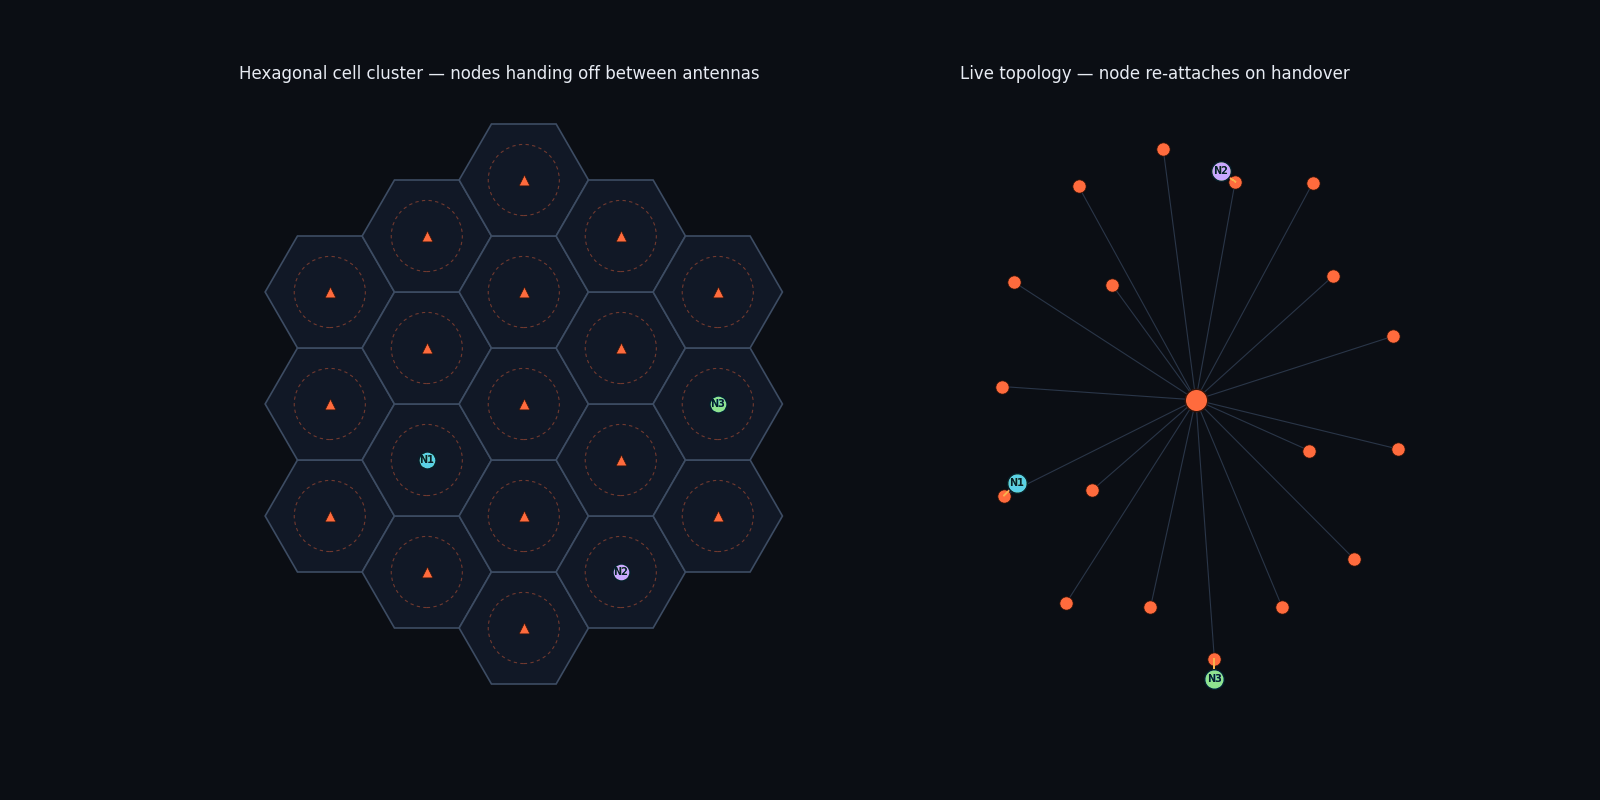

In [2]:
import math
import random
from datetime import datetime

import matplotlib
matplotlib.use("Agg")  # headless backend — required for saving animations in Colab
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
import networkx as nx
import pandas as pd

random.seed(7)

# ---------------------------------------------------------------------------
# Hex grid geometry (flat-top, axial coordinates — true edge-to-edge tiling)
# ---------------------------------------------------------------------------
HEX_SIZE = 5.2
RINGS = 2


def axial_to_pixel(q, r, size):
    return (size * 1.5 * q, size * math.sqrt(3) * (r + q / 2))


def hex_vertices(center, size):
    cx, cy = center
    return [(cx + size * math.cos(math.radians(60 * i)),
              cy + size * math.sin(math.radians(60 * i))) for i in range(6)]


def build_cluster(rings, size):
    centers, idx = {}, 0
    for q in range(-rings, rings + 1):
        for r in range(-rings, rings + 1):
            if max(abs(q), abs(r), abs(-q - r)) <= rings:
                centers[f"C{idx}"] = axial_to_pixel(q, r, size)
                idx += 1
    return centers


cell_centers = build_cluster(RINGS, HEX_SIZE)
cell_vertices = {c: hex_vertices(p, HEX_SIZE) for c, p in cell_centers.items()}
antennas = {f"A-{c}": p for c, p in cell_centers.items()}


def point_in_polygon(point, vertices):
    x, y = point
    inside = False
    x1, y1 = vertices[0]
    for i in range(1, len(vertices) + 1):
        x2, y2 = vertices[i % len(vertices)]
        if y > min(y1, y2) and y <= max(y1, y2) and x <= max(x1, x2):
            if y1 != y2:
                xin = (y - y1) * (x2 - x1) / (y2 - y1) + x1
            if x1 == x2 or x <= xin:
                inside = not inside
        x1, y1 = x2, y2
    return inside


def current_cell_of(point):
    """Which hexagon actually contains this point right now (or None)."""
    for cid, verts in cell_vertices.items():
        if point_in_polygon(point, verts):
            return cid
    return None


def distance(p1, p2):
    return math.hypot(p1[0] - p2[0], p1[1] - p2[1])


# ---------------------------------------------------------------------------
# Node travel paths: each node moves through a sequence of cells in order,
# crossing real hexagon boundaries along the way (straight lines between
# cell centers — the boundary crossing is detected live, not scripted).
# ---------------------------------------------------------------------------
NODE_PATHS = {
    "N1": ["C4", "C0", "C1", "C5"],
    "N2": ["C12", "C7", "C0", "C3", "C14"],
    "N3": ["C17", "C10", "C0", "C4"],
}
FRAMES_PER_LEG = 22

node_trajectories = {}
for nid, path in NODE_PATHS.items():
    pts = [cell_centers[c] for c in path]
    traj = []
    for a, b in zip(pts[:-1], pts[1:]):
        for t in range(FRAMES_PER_LEG):
            f = t / FRAMES_PER_LEG
            traj.append((a[0] + (b[0] - a[0]) * f, a[1] + (b[1] - a[1]) * f))
    node_trajectories[nid] = traj

TOTAL_FRAMES = max(len(t) for t in node_trajectories.values())
for nid in node_trajectories:  # hold last position if a node's path is shorter
    traj = node_trajectories[nid]
    while len(traj) < TOTAL_FRAMES:
        traj.append(traj[-1])

# ---------------------------------------------------------------------------
# Recording table state
# ---------------------------------------------------------------------------
attached_cell = {nid: None for nid in NODE_PATHS}
log_rows = []


def log_event(nid, cell, event):
    ant = f"A-{cell}"
    dist = distance(node_trajectories[nid][0], antennas[ant])  # placeholder, fixed below
    log_rows.append({
        "Time": datetime.now().strftime("%H:%M:%S"), "Node": nid,
        "Cell": cell, "Antenna": ant, "Event": event,
    })


# ---------------------------------------------------------------------------
# Styling
# ---------------------------------------------------------------------------
BG, CELL_FILL = "#0b0e14", "#111826"
ACCENT_ANTENNA, ACCENT_NODE = "#ff6b3d", "#5ad1e6"
ACCENT_SIGNAL, ACCENT_HANDOVER = "#ffce54", "#ff4d6d"
TEXT_MUTED, TEXT_BRIGHT = "#7c8798", "#e8ecf3"
NODE_COLORS = {"N1": "#5ad1e6", "N2": "#c9a8ff", "N3": "#8fe38f"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), facecolor=BG,
                                gridspec_kw={"width_ratios": [1.35, 1]})

# Static graph layout for antenna backbone (computed once, stays fixed)
G_static = nx.Graph()
for a in antennas:
    G_static.add_node(a)
for a in antennas:
    if a != "A-C0":
        G_static.add_edge("A-C0", a)
graph_pos = nx.spring_layout(G_static, seed=3)
node_offset = {"N1": (0.06, 0.05), "N2": (-0.07, 0.04), "N3": (0.0, -0.08)}

trail = {nid: [] for nid in NODE_PATHS}  # recent path breadcrumb per node


def draw_frame(frame_idx):
    ax1.clear()
    ax2.clear()
    ax1.set_facecolor(BG)
    ax2.set_facecolor(BG)

    # --- hex cells ---
    for verts in cell_vertices.values():
        ax1.add_patch(patches.Polygon(verts, closed=True, facecolor=CELL_FILL,
                                       edgecolor="#3d4c63", linewidth=1.2, zorder=1))
    for pos in antennas.values():
        ax1.add_patch(patches.Circle(pos, radius=HEX_SIZE * 0.55, fill=False,
                                      edgecolor=ACCENT_ANTENNA, linewidth=0.8,
                                      linestyle=(0, (3, 3)), alpha=0.4, zorder=2))
        ax1.scatter(*pos, s=60, marker="^", color=ACCENT_ANTENNA,
                    edgecolor="#3a1508", linewidth=0.5, zorder=3)

    handovers_this_frame = []

    for nid in NODE_PATHS:
        pos = node_trajectories[nid][frame_idx]
        cell = current_cell_of(pos) or attached_cell[nid]
        if cell != attached_cell[nid]:
            was_first = attached_cell[nid] is None
            event = "New entry recorded" if was_first else f"Handover ({attached_cell[nid]} -> {cell})"
            log_rows.append({
                "Time": datetime.now().strftime("%H:%M:%S"), "Node": nid,
                "Cell": cell, "Antenna": f"A-{cell}", "Event": event,
            })
            attached_cell[nid] = cell
            handovers_this_frame.append(nid)

        ant_pos = antennas[f"A-{cell}"]
        color = NODE_COLORS[nid]

        trail[nid].append(pos)
        if len(trail[nid]) > 14:
            trail[nid].pop(0)
        if len(trail[nid]) > 1:
            xs, ys = zip(*trail[nid])
            ax1.plot(xs, ys, color=color, linewidth=1.5, alpha=0.35, zorder=3)

        line_color = ACCENT_HANDOVER if nid in handovers_this_frame else ACCENT_SIGNAL
        ax1.plot([pos[0], ant_pos[0]], [pos[1], ant_pos[1]], color=line_color,
                  linewidth=1.3, alpha=0.7, zorder=4, solid_capstyle="round")
        ax1.scatter(*pos, s=150, color=color, edgecolor="#04202a",
                    linewidth=1, zorder=5)
        ax1.annotate(nid, pos, ha="center", va="center", fontsize=7,
                     color="#04202a", fontweight="bold", zorder=6)

        # graph panel: node sits near the antenna it's currently attached to
        gx, gy = graph_pos[f"A-{cell}"]
        ox, oy = node_offset[nid]
        gpos = (gx + ox, gy + oy)
        ax2.plot([gx, gpos[0]], [gy, gpos[1]], color=line_color,
                  linewidth=1.4, alpha=0.8, zorder=3)
        ax2.scatter(*gpos, s=200, color=color, edgecolor="#04202a",
                    linewidth=1, zorder=4)
        ax2.annotate(nid, gpos, ha="center", va="center", fontsize=7,
                     color="#04202a", fontweight="bold", zorder=5)

    nx.draw_networkx_edges(G_static, graph_pos, ax=ax2, edge_color="#2a3648", width=0.8)
    nx.draw_networkx_nodes(G_static, graph_pos, ax=ax2, node_color=ACCENT_ANTENNA,
                            node_size=90, edgecolors="#3a1508", linewidths=0.5)
    nx.draw_networkx_nodes(G_static, graph_pos, ax=ax2, nodelist=["A-C0"],
                            node_color=ACCENT_ANTENNA, node_size=260,
                            edgecolors="#3a1508", linewidths=1)

    ax1.set_aspect("equal")
    ax1.axis("off")
    ax1.set_title("Hexagonal cell cluster — nodes handing off between antennas",
                  color=TEXT_BRIGHT, fontsize=12, pad=12, loc="left")
    ax2.axis("off")
    ax2.set_title("Live topology — node re-attaches on handover",
                  color=TEXT_BRIGHT, fontsize=12, pad=12, loc="left")

    legend_items = [(ACCENT_ANTENNA, "Antenna"), (ACCENT_HANDOVER, "Handover event"),
                    (ACCENT_SIGNAL, "Active link")]
    for i, (c, t) in enumerate(legend_items):
        ax1.text(-0.02, -1.18 - i * 0.09, "●", color=c, fontsize=9,
                  transform=ax1.transAxes)
        ax1.text(0.01, -1.18 - i * 0.09, t, color=TEXT_MUTED, fontsize=8,
                  transform=ax1.transAxes, va="center")


anim = animation.FuncAnimation(fig, draw_frame, frames=TOTAL_FRAMES, interval=90)
fig.patch.set_facecolor(BG)
anim.save("hexagonal_cell_network.gif", writer=animation.PillowWriter(fps=12))

log_df = pd.DataFrame(log_rows)
print("\nRecording table (handover events included):\n")
print(log_df.to_string(index=False))
print("\nSaved: hexagonal_cell_network.gif")

# In Google Colab / Jupyter, saving the file does NOT display it automatically —
# this shows it inline in the notebook output. Safe to ignore outside a notebook.
try:
    from IPython.display import Image, display
    display(Image(filename="hexagonal_cell_network.gif"))
except ImportError:
    pass